Rows removed: 474
Upper bound: 472.50 seconds


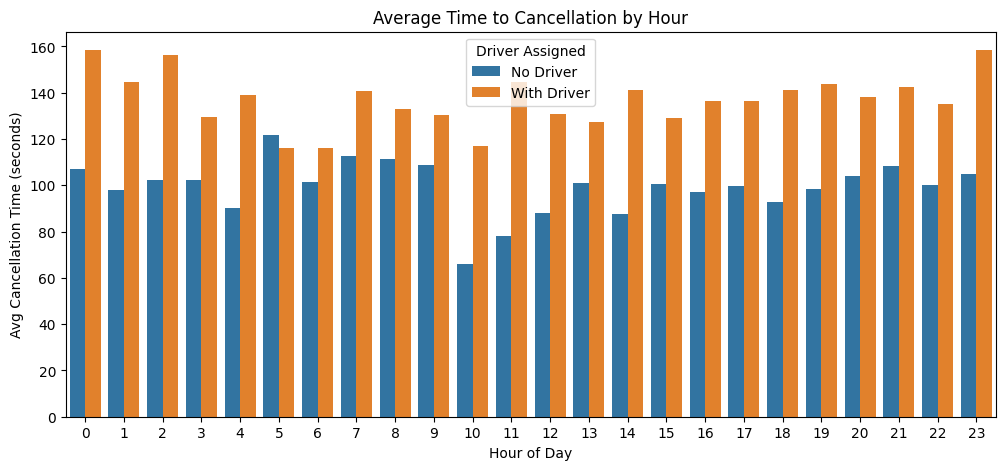

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv('data_orders.csv')
offers = pd.read_csv('data_offers.csv')

# Convert order_datetime to datetime and extract hour
orders['order_daytime'] = pd.to_datetime(orders['order_datetime'], format='%H:%M:%S').dt.hour

conditions = [
    (orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 0),
    (orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 1),
    (orders['order_status_key'] == 9)
]

labels = [
    'Cancelled - No Driver',
    'Cancelled - With Driver',
    'Rejected by System'
]
orders_cancelled = orders[orders['order_status_key'] == 4].copy()

Q1 = orders_cancelled['cancellations_time_in_seconds'].quantile(0.25)
Q3 = orders_cancelled['cancellations_time_in_seconds'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q1 + 3 * IQR

orders_clean = orders_cancelled[orders_cancelled['cancellations_time_in_seconds'] <= upper_bound]

print(f"Rows removed: {len(orders_cancelled) - len(orders_clean)}")
print(f"Upper bound: {upper_bound:.2f} seconds")

cancellation_time = orders_clean.groupby(['order_daytime', 'is_driver_assigned_key'])['cancellations_time_in_seconds'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=cancellation_time, x='order_daytime', y='cancellations_time_in_seconds', hue='is_driver_assigned_key')
plt.title("Average Time to Cancellation by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Cancellation Time (seconds)")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['No Driver', 'With Driver'], title='Driver Assigned')
plt.show()



The analysis focuses exclusively on client-initiated cancellations (order_status_key = 4). Outliers were removed using the IQR method with a 3×IQR upper bound (~401 seconds), retaining the vast majority of the data while eliminating only the most extreme values.

The chart reveals a consistent pattern across all hours of the day: customers who had a driver assigned waited significantly longer before cancelling compared to those who did not. This suggests that driver assignment creates a psychological commitment effect — once a customer knows a driver is on the way, they are more reluctant to cancel.

The gap between the two categories is especially pronounced during late night hours (0, 2, 23), where customers with an assigned driver waited up to 50 seconds longer on average before cancelling. The lowest patience levels for both groups are observed around hour 10, indicating that midday customers are the least willing to wait regardless of driver assignment status.

Key takeaway: Reducing the time to driver assignment is likely the single most effective intervention to reduce cancellation rates. Customers who receive a driver assignment are more patient and less likely to abandon their order.
